# Chương 2: Phân Tích Tăng Trưởng Khu Vực & Phát Hiện Bất Thường Doanh Số (Cập Nhật STL)

Notebook này thực hiện đúng và đầy đủ các yêu cầu phân tích của **Chương 2** trong tài liệu Storytelling với các nâng cấp tối ưu:
1. **EDA**: Phân tích xu hướng doanh thu, lợi nhuận và vẽ ma trận Tăng trưởng vs Quy mô (Growth vs Scale).
2. **Phân tích Khách hàng**: Đếm số lượng Active Customers, New Customers, Returning Customers theo tháng và lãnh thổ.
3. **Data Mining - PCA & K-Means**: 
   * Sử dụng **Profit Margin** (Lợi nhuận biên) thay cho Lợi nhuận gộp tuyệt đối.
   * Chuẩn hóa đặc trưng và áp dụng thuật toán **PCA** giảm chiều dữ liệu.
   * Thử nghiệm tham số $K$ từ 2 đến 6, tự động chọn $K$ tối ưu dựa trên **Silhouette Score** lớn nhất.
   * Gán nhãn động duy nhất cho các cụm dựa trên thứ tự xếp hạng centroids đa chiều.
4. **Data Mining - Phát hiện bất thường (Anomaly Detection)**: Phân rã chuỗi thời gian bằng thuật toán **STL** (Loess decomposition) mạnh mẽ và tính Z-score phần dư.
5. **So sánh với Forecast**: Đối chiếu thực tế với doanh thu dự báo để tính sai số dự báo (Forecast Error).
6. **Lưu kết quả**: Ghi kết quả phân tích ngược lại PostgreSQL DWH.

### 1. Cấu hình & Kết nối Database

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from statsmodels.tsa.seasonal import STL

# Thêm thư mục gốc vào path để import src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.database import get_dwh_engine

# Cấu hình biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

# Kết nối DWH
engine = get_dwh_engine()
print("Kết nối database DWH thành công!")

Kết nối database DWH thành công!


### 2. Tải Dữ Liệu Phân Tích Từ DWH

In [2]:
# Lấy dữ liệu Sales Mart kết hợp tính toán số lượng khách hàng hoạt động (Active, New, Returning) từ Fact Internet Sales
query = """
    WITH customer_first_purchase AS (
        SELECT 
            customer_key,
            MIN(order_date) as first_purchase_date
        FROM dwh.fact_internet_sales
        GROUP BY customer_key
    ),
    monthly_customer_stats AS (
        SELECT 
            TO_CHAR(f.order_date, 'YYYYMM') as month_key,
            f.territory_id,
            COUNT(DISTINCT f.customer_key) as active_customers,
            COUNT(DISTINCT CASE WHEN TO_CHAR(cfp.first_purchase_date, 'YYYYMM') = TO_CHAR(f.order_date, 'YYYYMM') THEN f.customer_key END) as new_customers
        FROM dwh.fact_internet_sales f
        JOIN customer_first_purchase cfp ON f.customer_key = cfp.customer_key
        GROUP BY TO_CHAR(f.order_date, 'YYYYMM'), f.territory_id
    )
    SELECT 
        m.month_key,
        m.territory_id,
        t.territory_name,
        t.country_code,
        SUM(m.revenue) as revenue,
        SUM(m.cogs) as cogs,
        SUM(m.gross_profit) as profit,
        SUM(m.orders) as orders,
        SUM(m.quantity) as quantity,
        COALESCE(c.active_customers, 0) as active_customers,
        COALESCE(c.new_customers, 0) as new_customers,
        COALESCE(c.active_customers, 0) - COALESCE(c.new_customers, 0) as returning_customers
    FROM mart.mart_sales_kpi_monthly m
    JOIN dwh.dim_sales_territory t ON m.territory_id = t.territory_id
    LEFT JOIN monthly_customer_stats c ON m.month_key = c.month_key AND m.territory_id = c.territory_id
    GROUP BY m.month_key, m.territory_id, t.territory_name, t.country_code, c.active_customers, c.new_customers
    ORDER BY m.month_key, m.territory_id
"""
df = pd.read_sql_query(query, engine)
print(f"Đã tải {len(df)} dòng dữ liệu từ DWH.")
df.head()

Đã tải 376 dòng dữ liệu từ DWH.


,month_key,territory_id,territory_name,country_code,revenue,cogs,profit,orders,quantity,active_customers,new_customers,returning_customers
0,202205,1,Northwest,US,97305.5951,91358.7941,5946.8010,15,96,7,7,0
1,202205,2,Northeast,US,21598.3855,23344.7976,-1746.4121,9,51,4,4,0
2,202205,3,Central,US,19243.0643,19155.0349,88.0294,10,40,4,4,0
3,202205,4,Southwest,US,104333.8017,109595.1030,-5261.3013,20,240,9,9,0
4,202205,5,Southeast,US,139164.1943,134234.6553,4929.5390,23,170,10,10,0


### 3. Khám Phá Dữ Liệu (EDA)

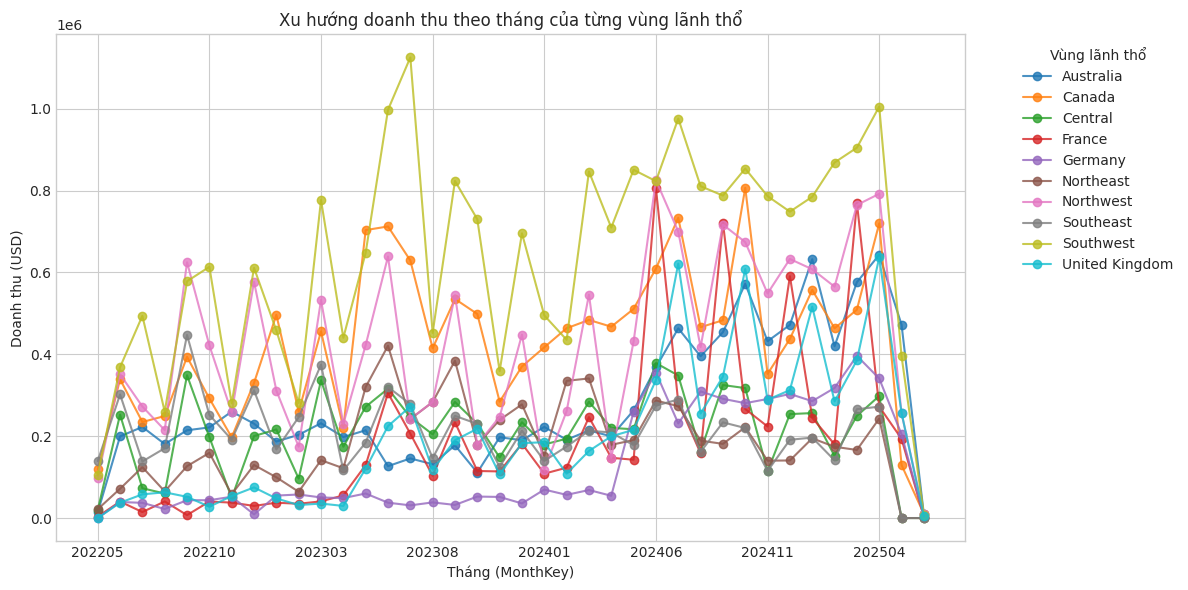

In [3]:
# 1. Vẽ xu hướng doanh thu theo khu vực lãnh thổ
df_pivot = df.pivot(index='month_key', columns='territory_name', values='revenue').fillna(0)
df_pivot.plot(kind='line', marker='o', alpha=0.8)
plt.title('Xu hướng doanh thu theo tháng của từng vùng lãnh thổ')
plt.xlabel('Tháng (MonthKey)')
plt.ylabel('Doanh thu (USD)')
plt.legend(title='Vùng lãnh thổ', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

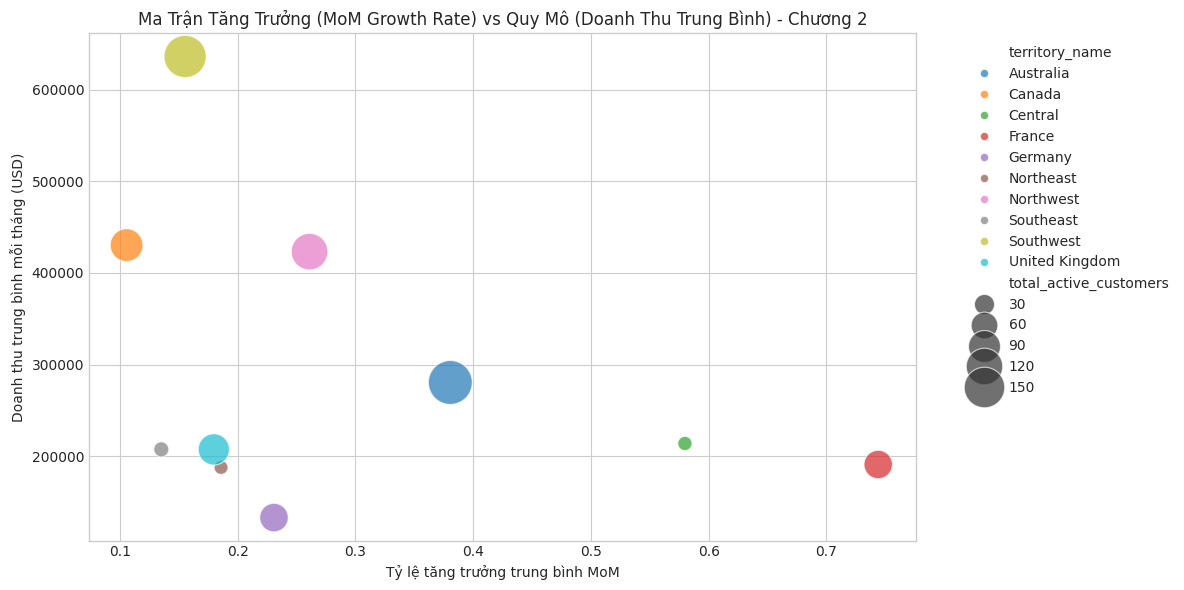

In [4]:
# 2. Tính tỷ lệ tăng trưởng doanh thu (MoM Growth) và độ biến động cho từng khu vực
df['prev_revenue'] = df.groupby('territory_id')['revenue'].shift(1)
df['mom_growth'] = (df['revenue'] - df['prev_revenue']) / df['prev_revenue']
df['mom_growth'] = df['mom_growth'].fillna(0)

# 3. Vẽ ma trận Tăng trưởng vs Quy mô (Growth vs Scale Bubble Chart)
summary = df.groupby('territory_name').agg(
    avg_revenue=('revenue', 'mean'),
    avg_growth=('mom_growth', 'mean'),
    total_profit=('profit', 'sum'),
    total_active_customers=('active_customers', 'mean')
).reset_index()

sns.scatterplot(
    data=summary, 
    x='avg_growth', 
    y='avg_revenue', 
    size='total_active_customers', 
    hue='territory_name', 
    sizes=(100, 1000), 
    alpha=0.7
)
plt.title('Ma Trận Tăng Trưởng (MoM Growth Rate) vs Quy Mô (Doanh Thu Trung Bình) - Chương 2')
plt.xlabel('Tỷ lệ tăng trưởng trung bình MoM')
plt.ylabel('Doanh thu trung bình mỗi tháng (USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Phân Cụm Lãnh Thổ Bằng K-Means & PCA (Data Mining)

In [5]:
# Chuẩn bị các đặc trưng phân cụm cho từng vùng
features_df = df.groupby(['territory_id', 'territory_name']).agg(
    mean_revenue=('revenue', 'mean'),
    mean_growth=('mom_growth', 'mean'),
    revenue_volatility=('revenue', 'std'),
    avg_active_customers=('active_customers', 'mean'),
    mean_profit=('profit', 'mean')
).reset_index()

features_df['revenue_volatility'] = features_df['revenue_volatility'].fillna(0)

# Tính Profit Margin = Profit / Revenue thay vì Profit tuyệt đối
features_df['mean_profit_margin'] = features_df['mean_profit'] / features_df['mean_revenue']
features_df['mean_profit_margin'] = features_df['mean_profit_margin'].fillna(0)

# Chuẩn hóa đặc trưng đa chiều
scaler = StandardScaler()
scaled_cols = ['mean_revenue', 'mean_growth', 'revenue_volatility', 'avg_active_customers', 'mean_profit_margin']
scaled_features = scaler.fit_transform(features_df[scaled_cols])

# Áp dụng PCA giảm chiều dữ liệu về 2 thành phần chính để khử tương quan & hỗ trợ vẽ biểu đồ
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_features)
features_df['pca_1'] = pca_features[:, 0]
features_df['pca_2'] = pca_features[:, 1]

print("PCA hoàn thành. Tỷ lệ phương sai giải thích:", pca.explained_variance_ratio_)

PCA hoàn thành. Tỷ lệ phương sai giải thích: [0.52882784 0.27965014]


In [6]:
# Tìm K tối ưu từ 2 đến 6 dựa trên Silhouette Score lớn nhất
best_k = 2
best_score = -1
scores = {}
inertias = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_features)
    score = silhouette_score(pca_features, labels)
    scores[k] = score
    inertias[k] = km.inertia_
    print(f"K = {k} | Silhouette Score = {score:.4f} | Inertia = {km.inertia_:.2f}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"\n===> K tối ưu được chọn tự động: K = {best_k} (Silhouette Score: {best_score:.4f})")

K = 2 | Silhouette Score = 0.3386 | Inertia = 21.20
K = 3 | Silhouette Score = 0.4817 | Inertia = 8.64
K = 4 | Silhouette Score = 0.4290 | Inertia = 5.68
K = 5 | Silhouette Score = 0.3916 | Inertia = 3.01
K = 6 | Silhouette Score = 0.3710 | Inertia = 1.96

===> K tối ưu được chọn tự động: K = 3 (Silhouette Score: 0.4817)


In [7]:
# Huấn luyện K-Means với K tối ưu trên tọa độ PCA
kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features_df['cluster_label'] = kmeans_opt.fit_predict(pca_features)

# Gán tên cụm động, duy nhất cho bất kỳ K nào dựa trên thuộc tính của centroids đa chiều
centroids = features_df.groupby('cluster_label')[['mean_revenue', 'mean_growth', 'revenue_volatility', 'avg_active_customers', 'mean_profit_margin']].mean()

# Hiển thị bảng Profile chi tiết trung bình của từng cụm trên dữ liệu thực tế để diễn giải rõ ràng
print("=== BẢNG CHỈ SỐ TRUNG BÌNH CỦA TỪNG CỤM PHÂN KHÚC THỊ TRƯỜNG ===")
profile_table = features_df.groupby('cluster_label')[[
    'mean_revenue', 'mean_profit_margin', 'mean_growth', 'revenue_volatility', 'avg_active_customers'
]].mean().reset_index()

# Định dạng bảng hiển thị cho đẹp
profile_table.columns = ['Cụm', 'Doanh Thu TB (USD)', 'Biên LN Gộp (Profit Margin)', 'Tăng Trưởng TB (MoM)', 'Độ Biến Động Doanh Số', 'Khách Hàng Hoạt Động TB']
profile_table.style.format({
    'Doanh Thu TB (USD)': '{:,.2f}',
    'Biên LN Gộp (Profit Margin)': '{:.2%}',
    'Tăng Trưởng TB (MoM)': '{:.2%}',
    'Độ Biến Động Doanh Số': '{:,.2f}',
    'Khách Hàng Hoạt Động TB': '{:,.1f}'
}).hide()

=== BẢNG CHỈ SỐ TRUNG BÌNH CỦA TỪNG CỤM PHÂN KHÚC THỊ TRƯỜNG ===


Cụm,Doanh Thu TB (USD),Biên LN Gộp (Profit Margin),Tăng Trưởng TB (MoM),Độ Biến Động Doanh Số,Khách Hàng Hoạt Động TB
0,"496,713.36",5.81%,17.40%,"221,472.13",126.2
1,"202,849.91",20.46%,38.37%,"167,205.97",100.6
2,"202,889.00",-2.53%,30.02%,"94,637.08",10.9


### Trực Quan Hóa Và Diễn Giải Phân Cụm Phục Vụ Doanh Nghiệp

In [8]:
cluster_names = {
    0: "Phân Khúc Chủ Lực (Doanh Thu & Quy Mô Khách Hàng Dẫn Đầu)",
    1: "Phân Khúc Tăng Trưởng Tiềm Năng (Biên Lợi Nhuận Cao & Tăng Trưởng Mạnh)",
    2: "Phân Khúc Hiệu Quả Thấp (Tăng Trưởng Nhưng Chưa Sinh Lợi)"
}

features_df['cluster_name'] = features_df['cluster_label'].map(cluster_names)
features_df

,territory_id,territory_name,mean_revenue,mean_growth,revenue_volatility,avg_active_customers,mean_profit,mean_profit_margin,pca_1,pca_2,cluster_label,cluster_name
0,1,Northwest,423287.961779,0.260970,218162.487283,120.473684,35910.576118,0.084837,1.410050,-0.425759,0,Phân Khúc Chủ Lực (Doanh Thu & Quy Mô Khách Hà...
1,2,Northeast,187550.661649,0.185808,99466.940705,9.513514,-7283.599570,-0.038835,-1.986101,-1.005609,2,Phân Khúc Hiệu Quả Thấp (Tăng Trưởng Nhưng Chư...
2,3,Central,213757.000159,0.579800,96140.592131,10.405405,-3850.020344,-0.018011,-2.094886,0.205606,2,Phân Khúc Hiệu Quả Thấp (Tăng Trưởng Nhưng Chư...
3,4,Southwest,636437.094758,0.155305,263497.601535,163.342105,41150.284490,0.064657,3.021888,-1.362271,0,Phân Khúc Chủ Lực (Doanh Thu & Quy Mô Khách Hà...
4,5,Southeast,207359.344004,0.135078,88303.705403,12.789474,-3975.195238,-0.019171,-1.917765,-1.081986,2,Phân Khúc Hiệu Quả Thấp (Tăng Trưởng Nhưng Chư...
5,6,Canada,430415.011970,0.105580,182756.304397,94.815789,10639.905388,0.024720,0.746418,-1.332894,0,Phân Khúc Chủ Lực (Doanh Thu & Quy Mô Khách Hà...
6,7,France,190830.411761,0.743967,206633.469618,69.210526,23502.491572,0.123159,-0.181859,1.750501,1,Phân Khúc Tăng Trưởng Tiềm Năng (Biên Lợi Nhuậ...
7,8,Germany,132848.853943,0.230780,126860.316148,69.756757,28189.640340,0.212193,-0.640972,0.967218,1,Phân Khúc Tăng Trưởng Tiềm Năng (Biên Lợi Nhuậ...
8,9,Australia,280403.577877,0.380541,162126.825473,177.684211,90375.141553,0.322304,1.514152,1.959240,1,Phân Khúc Tăng Trưởng Tiềm Năng (Biên Lợi Nhuậ...
9,10,United Kingdom,207316.784743,0.179680,173203.281470,85.675676,33294.841164,0.160599,0.129074,0.325953,1,Phân Khúc Tăng Trưởng Tiềm Năng (Biên Lợi Nhuậ...


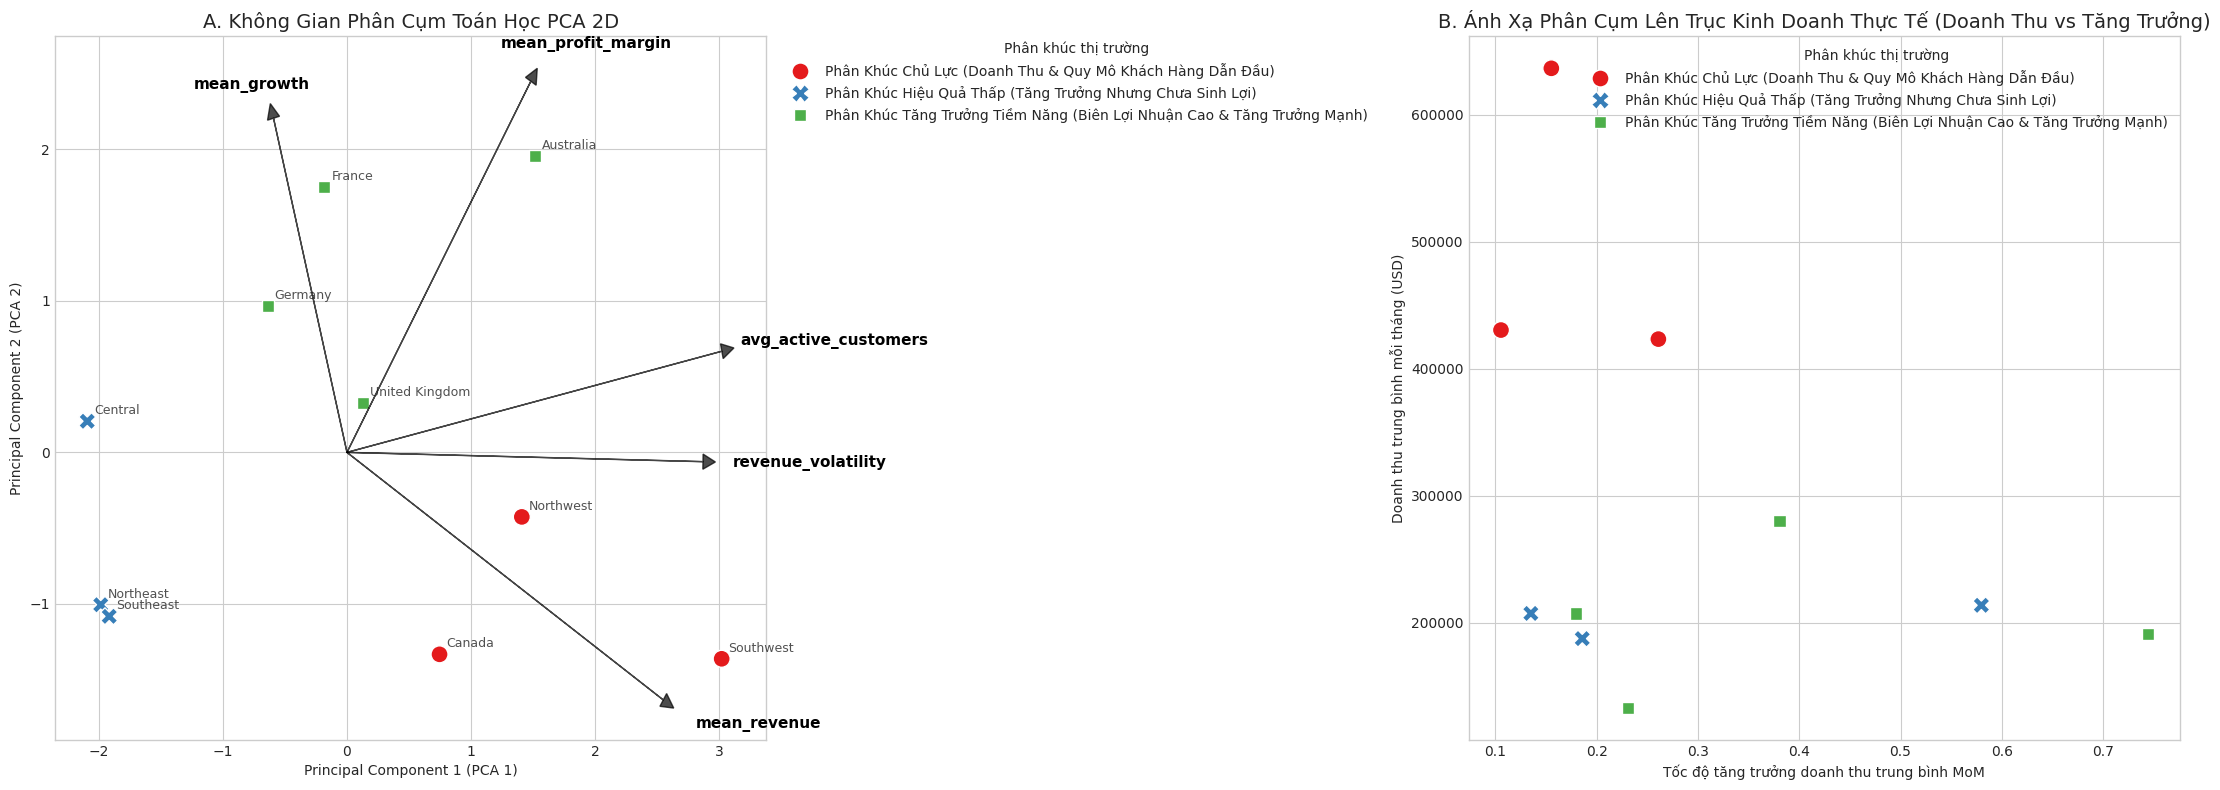

In [9]:
# Tạo 2 subplots để so sánh: Biểu đồ PCA (Toán học) vs Biểu đồ Doanh thu - Tăng trưởng (Kinh doanh)
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# 1. Biểu đồ 1: Phân cụm trong không gian toán học PCA 2D (có vẽ Vector đặc trưng - Biplot để giải thích chiều)
sns.scatterplot(
    data=features_df, x='pca_1', y='pca_2', hue='cluster_name', 
    style='cluster_name', s=150, palette='Set1', ax=axes[0]
)

# Vẽ các vector loadings của 5 đặc trưng gốc lên biểu đồ PCA
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, feature in enumerate(scaled_cols):
    axes[0].arrow(0, 0, loadings[i, 0] * 3, loadings[i, 1] * 3, color='black', alpha=0.7, head_width=0.1, head_length=0.1)
    axes[0].text(loadings[i, 0] * 3.9, loadings[i, 1] * 3.3, feature, color='black', ha='center', va='center', fontsize=11, weight='bold')

axes[0].set_title('A. Không Gian Phân Cụm Toán Học PCA 2D', fontsize=14)
axes[0].set_xlabel('Principal Component 1 (PCA 1)')
axes[0].set_ylabel('Principal Component 2 (PCA 2)')
axes[0].legend(
    title='Phân khúc thị trường',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.
)
for _, row in features_df.iterrows():
    axes[0].annotate(
        row["territory_name"],
        (row["pca_1"], row["pca_2"]),
        xytext=(5, 5),          # lệch 5 pixel
        textcoords="offset points",
        fontsize=9,
        alpha=0.8
    )
# 2. Biểu đồ 2: Ánh xạ cụm ngược về các trục kinh doanh thực tế (Doanh thu vs Tốc độ tăng trưởng) để sếp dễ đọc
sns.scatterplot(
    data=features_df, x='mean_growth', y='mean_revenue', hue='cluster_name', 
    style='cluster_name', s=150, palette='Set1', ax=axes[1]
)
axes[1].set_title('B. Ánh Xạ Phân Cụm Lên Trục Kinh Doanh Thực Tế (Doanh Thu vs Tăng Trưởng)', fontsize=14)
axes[1].set_xlabel('Tốc độ tăng trưởng doanh thu trung bình MoM')
axes[1].set_ylabel('Doanh thu trung bình mỗi tháng (USD)')
axes[1].legend(title='Phân khúc thị trường', loc='upper right')

plt.tight_layout()
plt.show()

### 5. Phát Hiện Biến Động Doanh Số Bất Thường Bằng Thuật Toán STL (Data Mining)

In [10]:
# Tạo bảng ghi nhận bất thường
anomaly_results = []

# Phân tích bất thường cho từng khu vực bằng phân rã chuỗi thời gian mạnh mẽ STL (robust=True để giảm nhiễu outlier)
for tid in df['territory_id'].unique():
    sub_df = df[df['territory_id'] == tid].copy()
    sub_df['date'] = pd.to_datetime(sub_df['month_key'], format='%Y%m')
    sub_df = sub_df.set_index('date').sort_index()
    
    if len(sub_df) < 12:
        # Nếu chuỗi thời gian quá ngắn, tính Z-score trực tiếp trên doanh thu
        rev_mean = sub_df['revenue'].mean()
        rev_std = sub_df['revenue'].std() or 1.0
        sub_df['residual_z'] = (sub_df['revenue'] - rev_mean) / rev_std
    else:
        # Phân rã chuỗi thời gian bằng STL (Loess decomposition) mạnh mẽ với nhiễu ngoại lai
        stl = STL(sub_df['revenue'], period=12, robust=True)
        res = stl.fit()
        residual = res.resid
        # Tính Z-score trên phần dư của STL
        sub_df['residual_z'] = (residual - residual.mean()) / (residual.std() or 1.0)
        
    sub_df['is_anomaly'] = np.abs(sub_df['residual_z']) > 2.0
    sub_df = sub_df.reset_index()
    anomaly_results.append(sub_df[['month_key', 'territory_id', 'residual_z', 'is_anomaly']])

anomaly_df = pd.concat(anomaly_results)
df = df.merge(anomaly_df, on=['month_key', 'territory_id'], how='left')
print(f"Tìm thấy {df['is_anomaly'].sum()} tháng biến động bất thường trên toàn bộ khu vực.")
df[df['is_anomaly'] == True].head()

Tìm thấy 24 tháng biến động bất thường trên toàn bộ khu vực.


,month_key,territory_id,territory_name,country_code,revenue,cogs,profit,orders,quantity,active_customers,new_customers,returning_customers,prev_revenue,mom_growth,residual_z,is_anomaly
119,202305,2,Northeast,US,320044.849652,330945.7743,-10900.924648,23,878,7,4,3,121668.652857,1.630463,2.793314,True
120,202305,3,Central,US,271827.374798,296719.0518,-24891.677002,25,837,8,5,3,174232.486925,0.560142,4.045253,True
123,202305,6,Canada,CA,703337.417222,710338.1280,-7000.710778,53,1877,30,25,5,220539.207175,2.189172,3.356632,True
128,202306,1,Northwest,US,638916.189306,619934.9222,18981.267106,94,1748,61,52,9,422431.416932,0.512473,2.320127,True
129,202306,2,Northeast,US,420788.225369,440896.8258,-20108.600431,40,1317,15,9,6,320044.849652,0.314779,2.135034,True


### 6. So Sánh Với Doanh Thu Dự Báo (Forecast Error)

In [11]:
# Kiểm tra xem bảng dự báo ml.revenue_forecast_predictions đã tồn tại chưa
table_exists = pd.read_sql_query("""
    SELECT EXISTS (
        SELECT FROM information_schema.tables 
        WHERE table_schema = 'ml' 
        AND table_name = 'revenue_forecast_predictions'
    );
""", engine).iloc[0, 0]

if table_exists:
    print("Tìm thấy bảng dự báo. Đang nạp sai số dự báo...")
    forecast_df = pd.read_sql_query("SELECT month_key, territory_id, predicted_revenue FROM ml.revenue_forecast_predictions", engine)
    df = df.merge(forecast_df, on=['month_key', 'territory_id'], how='left')
    df['forecast_error'] = df['revenue'] - df['predicted_revenue']
else:
    print("WARNING: Chưa tìm thấy bảng dự báo ml.revenue_forecast_predictions.")
    print("-> Hãy chạy lệnh 'make train-all' ở terminal trước để huấn luyện mô hình dự báo.")
    df['predicted_revenue'] = np.nan
    df['forecast_error'] = np.nan

df.head()

Tìm thấy bảng dự báo. Đang nạp sai số dự báo...


,month_key,territory_id,territory_name,country_code,revenue,cogs,profit,orders,quantity,active_customers,new_customers,returning_customers,prev_revenue,mom_growth,residual_z,is_anomaly,predicted_revenue,forecast_error
0,202205,1,Northwest,US,97305.5951,91358.7941,5946.8010,15,96,7,7,0,NaN,0.0,-0.053166,False,NaN,NaN
1,202205,2,Northeast,US,21598.3855,23344.7976,-1746.4121,9,51,4,4,0,NaN,0.0,-0.556639,False,NaN,NaN
2,202205,3,Central,US,19243.0643,19155.0349,88.0294,10,40,4,4,0,NaN,0.0,-0.267984,False,NaN,NaN
3,202205,4,Southwest,US,104333.8017,109595.1030,-5261.3013,20,240,9,9,0,NaN,0.0,-0.310876,False,NaN,NaN
4,202205,5,Southeast,US,139164.1943,134234.6553,4929.5390,23,170,10,10,0,NaN,0.0,-0.166833,False,NaN,NaN


### 7. Ghi Kết Quả Vào Database DWH Phục Vụ Superset

In [12]:
# Merge kết quả phân cụm và bất thường
output_db = df.merge(
    features_df[['territory_id', 'cluster_label', 'cluster_name']], 
    on='territory_id', 
    how='left'
)

# Chọn các cột đúng chuẩn của Storytelling
output_db = output_db[[
    'month_key', 'territory_id', 'revenue', 'profit', 'mom_growth', 'orders',
    'active_customers', 'new_customers', 'returning_customers',
    'cluster_label', 'cluster_name', 'residual_z', 'is_anomaly',
    'predicted_revenue', 'forecast_error'
]]

output_db['is_anomaly'] = output_db['is_anomaly'].astype(int)

# Ghi đè vào bảng kết quả của schema ml
output_db.to_sql(
    name='territory_analysis_results', 
    con=engine, 
    schema='ml', 
    if_exists='replace', 
    index=False
)

print("Thành công: Đã lưu bảng kết quả hoàn chỉnh vào ml.territory_analysis_results!")

Thành công: Đã lưu bảng kết quả hoàn chỉnh vào ml.territory_analysis_results!
